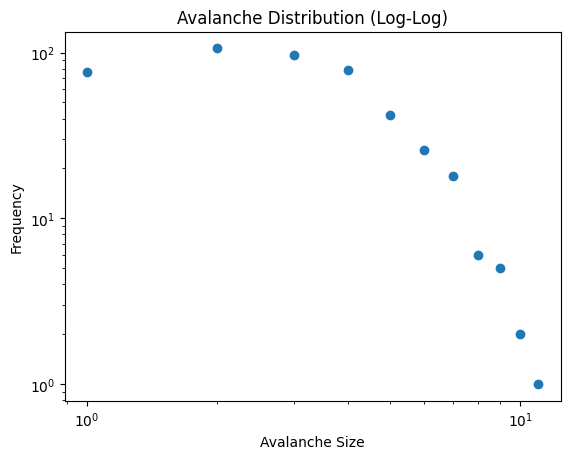

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

np.random.seed(42)

# Parameters
N = 500
threshold = 1.0
alpha = 0.5
beta = 0.2
noise_strength = 0.1
steps = 500

# Create network (scale-free for realism)
G = nx.barabasi_albert_graph(N, 3)

# Initialize engagement
E = np.random.rand(N) * 0.5

def simulate():
    avalanche_sizes = []

    for _ in range(steps):
        E[:] += np.random.normal(0, noise_strength, N)

        active = list(np.where(E > threshold)[0])
        visited = set(active)

        avalanche_size = 0

        while active:
            new_active = []
            for node in active:
                neighbors = list(G.neighbors(node))
                for nbr in neighbors:
                    if nbr not in visited:
                        E[nbr] += alpha * E[node] / max(len(neighbors),1)
                        if E[nbr] > threshold:
                            new_active.append(nbr)
                            visited.add(nbr)

                E[node] *= beta
                avalanche_size += 1

            active = new_active

        if avalanche_size > 0:
            avalanche_sizes.append(avalanche_size)

    return avalanche_sizes

sizes = simulate()

# Plot
count = Counter(sizes)
x, y = zip(*sorted(count.items()))

plt.loglog(x, y, 'o')
plt.xlabel("Avalanche Size")
plt.ylabel("Frequency")
plt.title("Avalanche Distribution (Log-Log)")
plt.show()


RANDOM
Mean: 4.43068783068783
Max: 21
Median: 4.0
Power-law exponent: 11.237018271466825

SMALL_WORLD
Mean: 3.966137566137566
Max: 14
Median: 3.0
Power-law exponent: 13.148897276905737

SCALE_FREE
Mean: 5.041922290388548
Max: 16
Median: 5.0
Power-law exponent: 9.275584379476669


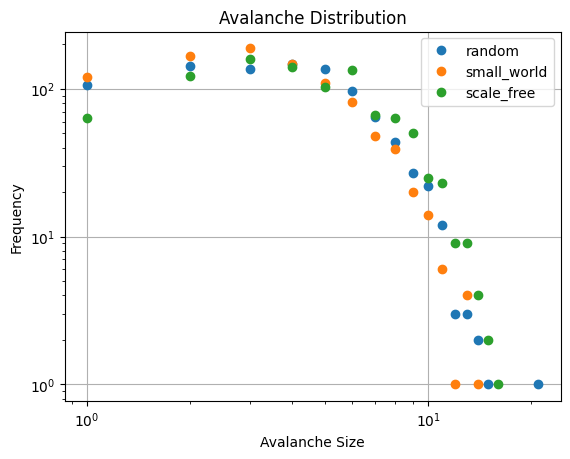

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter

np.random.seed(42)

# PARAMETERS
N = 800
threshold = 1.0
alpha = 0.6
beta = 0.3
noise_strength = 0.08
steps = 1000

def create_network(net_type, param=3):
    if net_type == "random":
        return nx.erdos_renyi_graph(N, param/N)
    elif net_type == "small_world":
        return nx.watts_strogatz_graph(N, param, 0.1)
    elif net_type == "scale_free":
        return nx.barabasi_albert_graph(N, param)

def simulate(G):
    E = np.random.rand(N) * 0.5
    avalanche_sizes = []
    time_series = []

    for _ in range(steps):
        E += np.random.normal(0, noise_strength, N)

        active = list(np.where(E > threshold)[0])
        visited = set(active)
        avalanche_size = 0

        while active:
            new_active = []
            for node in active:
                neighbors = list(G.neighbors(node))
                k = max(len(neighbors), 1)

                for nbr in neighbors:
                    if nbr not in visited:
                        E[nbr] += alpha * E[node] / k
                        if E[nbr] > threshold:
                            new_active.append(nbr)
                            visited.add(nbr)

                E[node] *= beta
                avalanche_size += 1

            active = new_active

        time_series.append(avalanche_size)

        if avalanche_size > 0:
            avalanche_sizes.append(avalanche_size)

    return avalanche_sizes, time_series

def power_law_fit(data, xmin=10):
    data = np.array([x for x in data if x >= xmin])
    if len(data) == 0:
        return None
    alpha = 1 + len(data) / np.sum(np.log(data/xmin))
    return alpha

results = {}

for net in ["random", "small_world", "scale_free"]:
    G = create_network(net)
    sizes, ts = simulate(G)
    results[net] = sizes

    print(f"\n{net.upper()}")
    print("Mean:", np.mean(sizes))
    print("Max:", np.max(sizes))
    print("Median:", np.median(sizes))
    print("Power-law exponent:", power_law_fit(sizes))

# PLOT
plt.figure()
for net in results:
    count = Counter(results[net])
    x, y = zip(*sorted(count.items()))
    plt.loglog(x, y, 'o', label=net)

plt.xlabel("Avalanche Size")
plt.ylabel("Frequency")
plt.legend()
plt.title("Avalanche Distribution")
plt.grid()
plt.show()